In [1]:
using LATeachingSuite, GenLAProblems, LinearAlgebra, RowEchelon, Latexify, LaTeXStrings, Random
sympy = LATeachingSuite.sympy
mm_to_px(mm) = mm * 96 / 25.4
println( "  matrixlayout:  ", ml_version(), ",      ", ml_build())
println( "  LAFigureSpecs:    ", la_version(), ",      ", la_build())
println( "  GenLAProblems: ", GenLAProblems.__version__, ",  ", GenLAProblems.__build__)
;

  matrixlayout:  0.0.1,      4549693 2026-02-06T16:01:30-05:00
  LAFigureSpecs:    0.0.1,      8e84e70 2026-02-06T17:43:30-05:00
  GenLAProblems: 1.0.1,  unknown


<div style="float:center;width:100%;text-align:center;">
<strong style="height:100px;color:darkred;font-size:40px;">Problem Review</strong>
</div>

# 1. GE/GJ Problems

## 1.1 Gaussian Elimination (GE)

### 1.1.1  GE and Backsubstitution

#### **Consistent System**

In [47]:
M=3; N=5; r=3  # M is the number of rows, N the number of cols, r the number of pivots
# --------------------------------------------------------
A,X,B = gen_gj_pb(M,N,r; maxint=2, pivot_in_first_col=true, num_rhs=1,has_zeros=true)
pb_ge = ShowGE{Rational{Int}}( A,  B)
l_show( L"A =", A, L"\quad b=", B )

L"$A = \left(\begin{array}{rrrrr}
-1 & 1 & 2 & 4 & 4 \\
-2 & 2 & 4 & 6 & 12 \\
-2 & 2 & 4 & 10 & 6 \\
\end{array}\right) \quad b= \left(\begin{array}{r}
-10 \\
-22 \\
-20 \\
\end{array}\right)$"

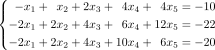

In [48]:
show_system( pb_ge, b_mat=1, b_col=1, fig_scale=1.2 )

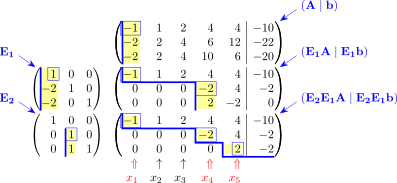

In [49]:
ref!(pb_ge, gj=false)               # perform gaussian elimination
show_layout!(pb_ge, fig_scale=1.2)  # show the computational layout

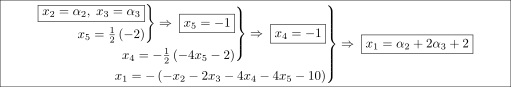

In [50]:
show_backsubstitution!(pb_ge, b_mat=1, b_col=1, fig_scale=1.3, render_opts=Dict("padding" => (mm_to_px(10), mm_to_px(10), 4, 4), "frame" => true))

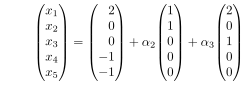

In [51]:
show_solution!(pb_ge, b_mat=1, b_col=1, fig_scale=1.3, render_opts=Dict( "padding" => (mm_to_px(10), 4, 4, 4)))

In [56]:
Xp, Xh = solutions(pb_ge; b_mat=1)
l_show( L"B =", rhs_matrix(pb_ge, 1), L",\quad x_p =", Xp, L"\quad x_h = ", Xh, symbol_vector("α",pb_ge.free_cols))

L"$B = \left(\begin{array}{r}
-10 \\
-2 \\
-2 \\
\end{array}\right) ,\quad x_p = \left(\begin{array}{r}
2 \\
0 \\
0 \\
-1 \\
-1 \\
\end{array}\right) \quad x_h = \left(\begin{array}{rr}
1 & 2 \\
1 & 0 \\
0 & 1 \\
0 & 0 \\
0 & 0 \\
\end{array}\right) \left(\begin{array}{r}
\alpha_{2} \\
\alpha_{3} \\
\end{array}\right)$"

In [63]:
# check the solution
@show pb_ge.A * Xp == B;

pb_ge.A * Xp == B = true


In [ ]:
display( pr( "Details of the computations are kept in the ShowGE{} structure"; color=:blue, sz=20, height=25 ))
for name in fieldnames(typeof(pb_ge))
  if isdefined(pb_ge, name)
     if name == :desc || name == :h
          println(name, " ... ")
      else
          println(name, " = ", getfield(pb_ge, name))
      end
  else
      println(name, " = <undef>")
  end
end

#### **Inconsistent System**

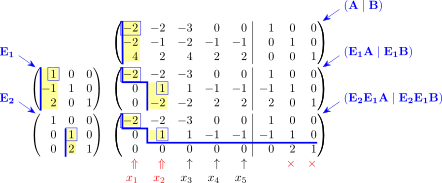

L"$\text{Solution for } A x = b_3$"

Rational{Int64}[]

L"$B_{consistent} = \left(\begin{array}{r}
1 \\
-1 \\
0 \\
\end{array}\right) ,\qquad x_p = \frac{1}{2} \left(\begin{array}{rrr}
1 & 0 & 0 \\
-2 & 0 & 0 \\
0 & 0 & 0 \\
0 & 0 & 0 \\
0 & 0 & 0 \\
\end{array}\right) \quad x_h = \frac{1}{2} \left(\begin{array}{rrr}
-1 & -2 & -2 \\
-2 & 2 & 2 \\
2 & 0 & 0 \\
0 & 2 & 0 \\
0 & 0 & 2 \\
\end{array}\right)$"

In [10]:
Random.seed!(4562)
A,X,B = gen_gj_pb(3,5,2; maxint=2, pivot_in_first_col=true, num_rhs=0,has_zeros=true)
pb_x = ShowGE{Rational{Int}}( A,  Matrix(one(eltype(A))I(M)) )
ref!(pb_x, gj=false)               # perform gaussian elimination
display(show_layout!(pb_x, fig_scale=1.2))  # show the computational layout

display(l_show("Solution for ", L"A x = b_3"))
display(show_backsubstitution!(pb_x, b_mat=1, b_col=3, fig_scale=1.3,
        render_opts=Dict( "crop" => "tight", "padding" => (mm_to_px(10), 4, 4, 4), "frame" => true),
))

display(show_solution!(pb_x, b_mat=1, b_col=3, fig_scale=1.3))
Xp, Xh = solutions(pb_x; b_mat=1)
display(l_show( L"B_{consistent} =", rhs_matrix(pb_x, 1)[:,pb_x.rhs_consistent], L",\qquad x_p =", Xp[:,pb_x.rhs_consistent], L"\quad x_h = ", Xh, symbol_vector(L"\alpha", pb_x.free_cols)))

### 1.1.2 Special Case Normal Equation

In [11]:
M=3; N=4; r=2
A,X,B = gen_gj_pb(M,N,r; maxint=2, pivot_in_first_col=true, num_rhs=1,has_zeros=true)
pb_least_squares = ShowGE{Rational{Int}}( A, B )
l_show( L"A =", A, L"\quad b=", B )

L"$A = \left(\begin{array}{rrrr}
2 & 2 & -2 & 0 \\
2 & 2 & -2 & 1 \\
4 & 4 & -4 & 2 \\
\end{array}\right) \quad b= \left(\begin{array}{r}
4 \\
3 \\
6 \\
\end{array}\right)$"

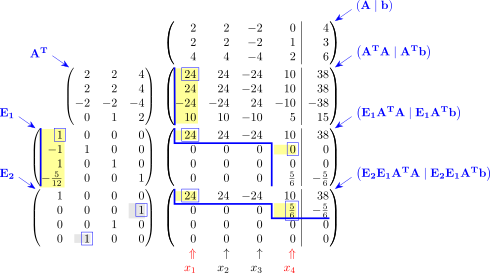

In [12]:
ref!(pb_least_squares, normal_eq=true)
show_layout!(pb_least_squares, fig_scale=1.2)

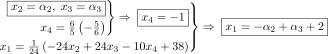

In [13]:
show_backsubstitution!(pb_least_squares, b_mat=1, b_col=1, fig_scale=1.2)

### 1.1.3 Projection Matrix from Normal Equations

In [14]:
A =  gen_full_col_rank_matrix( (1,1,2),3; maxint=2 )
P =  ca_projection_matrix( A )
@show P == A*inv(A'A)*A'
l_show( L"\qquad A = ", A, L",\qquad P = A (A^T A)^{-1} A^T = ", P)

P == A * inv(A' * A) * A' = true


L"$\qquad A = \left(\begin{array}{rrr}
0 & 1 & 0 \\
-2 & -2 & -4 \\
-2 & 0 & 0 \\
0 & -1 & -2 \\
\end{array}\right) ,\qquad P = A (A^T A)^{-1} A^T = \frac{1}{6} \left(\begin{array}{rrrr}
6 & 0 & 0 & 0 \\
0 & 5 & 1 & 2 \\
0 & 1 & 5 & -2 \\
0 & 2 & -2 & 2 \\
\end{array}\right)$"

## 1.2 Inverse Problems

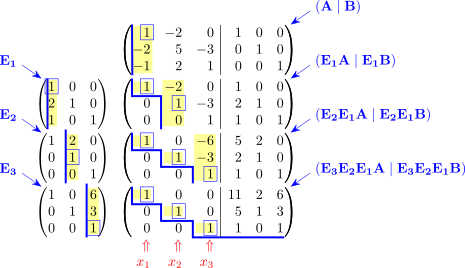

L"$A^{-1} = \left(\begin{array}{rrr}
11 & 2 & 6 \\
5 & 1 & 3 \\
1 & 0 & 1 \\
\end{array}\right)$"

A_inv == rhs_matrix(pb_inv, 1; step = :final) = true


In [15]:
A, A_inv  = gen_inv_pb(3, maxint=3)
pb_inv    = ShowGE{Rational{Int}}( A, 1I(size(A,1)) )
ref!(pb_inv, gj=true)
display(show_layout!(pb_inv, fig_scale=1.4))
display( l_show(L"A^{-1} = ", pb_inv.status == :consistent ? rhs_matrix(pb_inv, 1; step=:final) : "the inverse does not exist"))
@show A_inv == rhs_matrix(pb_inv, 1; step=:final);

## 1.3 LU and PLU Problems

### 1.3.1 LU Example

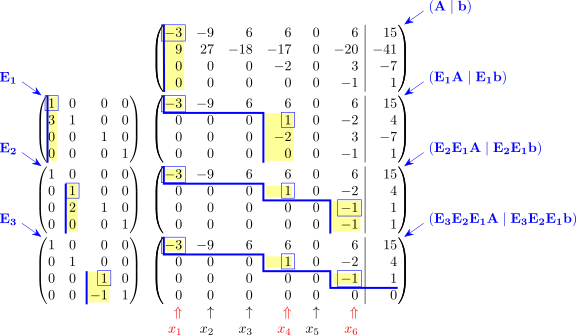

In [16]:
Random.seed!(5003)
m,n,r=4,6,3
pivot_cols, L, U, A = gen_lu_pb(m,n,r, maxint=3)
x,b                 = gen_rhs(A, pivot_cols)

pb_lu    = ShowGE{Rational{Int}}( A, b )
ref!(pb_lu)
display(show_layout!(pb_lu, fig_scale=1.4))

In [17]:
L_pb = [inv(m[1]) for m in pb_lu.matrices if m[1] !== nothing]
display(l_show( L"L = ", L_pb..., L" = ", prod(L_pb)))
@show prod(L_pb) == L;

L"$L = \left(\begin{array}{rrrr}
1 & 0 & 0 & 0 \\
-3 & 1 & 0 & 0 \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1 \\
\end{array}\right) \left(\begin{array}{rrrr}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & -2 & 1 & 0 \\
0 & 0 & 0 & 1 \\
\end{array}\right) \left(\begin{array}{rrrr}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 1 & 0 \\
0 & 0 & 1 & 1 \\
\end{array}\right) = \left(\begin{array}{rrrr}
1 & 0 & 0 & 0 \\
-3 & 1 & 0 & 0 \\
0 & -2 & 1 & 0 \\
0 & 0 & 1 & 1 \\
\end{array}\right)$"

prod(L_pb) == L = true


LAlatex.HTMLOut("<div style=\"font-size: 20px; color: blue; text-align: left; height: 25px; width: 100%; overflow-wrap: anywhere;\">\n  <p>Forward Substitution: solve L y = b</p>\n</div>\n")

nothing

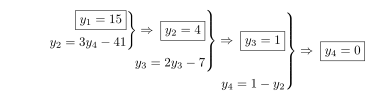

LAlatex.HTMLOut("<div style=\"font-size: 20px; color: blue; text-align: left; height: 25px; width: 100%; overflow-wrap: anywhere;\">\n  <p>Backward Substitution is now the standard backward substitution problem U x = y</p>\n</div>\n")

In [18]:
pr("Forward Substitution: solve L y = b", color=:blue, sz=20, height=25)
display(show_forwardsubstitution(L, b; var_name="y", fig_scale=1.3, render_opts=Dict("crop"=>"tight", "padding"=>(50,10,10,10))))
pr("Backward Substitution is now the standard backward substitution problem U x = y", color=:blue, sz=20, height=25)

### 1.3.2 PLU Example

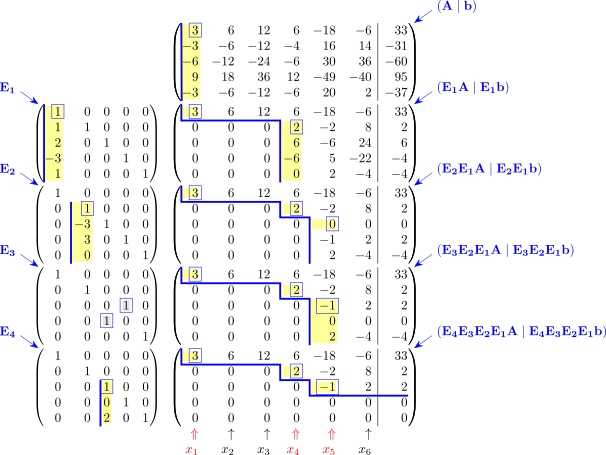

In [19]:
Random.seed!(5004)
pivot_cols,P,L,U,A        = gen_plu_pb(5,6,3)
x,b                       = gen_rhs(A, pivot_cols)

pb_plu = ShowGE{Rational{Int}}( A,  b )
ref!(pb_plu)
show_layout!(pb_plu, fig_scale=1.3)

In [20]:
L_plu = [inv(m[1]) for m in pb_plu.matrices if m[1] !== nothing]
display(l_show( L"L = ", L_plu...))
l_show( L"P L U = ", P, L, U )

"\$L = \\left(\\begin{array}{rrrrr}\n1 & 0 & 0 & 0 & 0 \\\\\n-1 & 1 & 0 & 0 & 0 \\\\\n-2 & 0 & 1 & 0 & 0 \\\\\n3 & 0 & 0 & 1 & 0 \\\\\n-1 & 0 & 0 & 0 & 1 \\\\\n\\end{array}\\right) \\left(\\begin{array}{rrrrr}\n1 & 0 & 0 & 0 & 0 \\\\\n0 & 1 & 0 & 0 & 0 \\\\\n0 & 3 & 1 & 0 & 0 \\\\\n0 & -3 & 0 & 1 & 0 \\\\\n" ⋯ 72 bytes ⋯ " & 0 & 0 & 0 \\\\\n0 & 1 & 0 & 0 & 0 \\\\\n0 & 0 & 0 & 1 & 0 \\\\\n0 & 0 & 1 & 0 & 0 \\\\\n0 & 0 & 0 & 0 & 1 \\\\\n\\end{array}\\right) \\left(\\begin{array}{rrrrr}\n1 & 0 & 0 & 0 & 0 \\\\\n0 & 1 & 0 & 0 & 0 \\\\\n0 & 0 & 1 & 0 & 0 \\\\\n0 & 0 & 0 & 1 & 0 \\\\\n0 & 0 & -2 & 0 & 1 \\\\\n\\end{array}\\right)\$"

L"$P L U = \left(\begin{array}{rrrrr}
1 & 0 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 & 0 \\
0 & 0 & 0 & 1 & 0 \\
0 & 0 & 1 & 0 & 0 \\
0 & 0 & 0 & 0 & 1 \\
\end{array}\right) \left(\begin{array}{rrrrr}
1 & 0 & 0 & 0 & 0 \\
-1 & 1 & 0 & 0 & 0 \\
3 & -3 & 1 & 0 & 0 \\
-2 & 3 & 0 & 1 & 0 \\
-1 & 0 & -2 & 3 & 1 \\
\end{array}\right) \left(\begin{array}{rrrrrr}
3 & 6 & 12 & 6 & -18 & -6 \\
0 & 0 & 0 & 2 & -2 & 8 \\
0 & 0 & 0 & 0 & -1 & 2 \\
0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 \\
\end{array}\right)$"

LAlatex.HTMLOut("<div style=\"font-size: 20px; color: blue; text-align: left; height: 25px; width: 100%; overflow-wrap: anywhere;\">\n  <p>Solve P w = b</p>\n</div>\n")

nothing

L"$P w = b \Leftrightarrow w = P^T b = \left(\begin{array}{r}
33 \\
-31 \\
95 \\
-60 \\
-37 \\
\end{array}\right)$"

LAlatex.HTMLOut("<div style=\"font-size: 20px; color: blue; text-align: left; height: 25px; width: 100%; overflow-wrap: anywhere;\">\n  <p>Forward Substitution: solve L y = w</p>\n</div>\n")

nothing

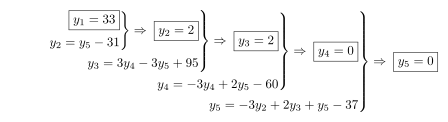

LAlatex.HTMLOut("<div style=\"font-size: 20px; color: blue; text-align: left; height: 25px; width: 100%; overflow-wrap: anywhere;\">\n  <p>Backward Substitution is now the standard backward substitution problem U x = y</p>\n</div>\n")

In [21]:
pr("Solve P w = b", color=:blue, sz=20, height=25)
w = P'*b
display(l_show( L"P w = b \Leftrightarrow w = P^T b = ", w))
pr("Forward Substitution: solve L y = w", color=:blue, sz=20, height=25)
display(show_forwardsubstitution(L, w; var_name="y", fig_scale=1.3, render_opts=Dict("crop"=>"tight", "padding"=>(50,10,10,10))))
pr("Backward Substitution is now the standard backward substitution problem U x = y", color=:blue, sz=20, height=25)

### 1.3.3 $LDL^T$ Problem

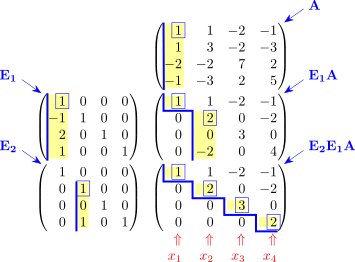

In [22]:
Random.seed!(4185)

L,D,A    = gen_ldlt_pb(4)
pb_ldlt  = ShowGE{Rational{Int}}( A )
ref!(pb_ldlt)
display(show_layout!(pb_ldlt, fig_scale=1.4))

In [23]:
D = Diagonal(pb_ldlt.matrices[end][end])
LDLt = L*D*L'
display(l_show( L"A = L D L^t = \quad", Int.(L),Int.(D), Int.(L)'))
@show A == LDLt;

L"$A = L D L^t = \quad \left(\begin{array}{rrrr}
1 & 0 & 0 & 0 \\
1 & 1 & 0 & 0 \\
-2 & 0 & 1 & 0 \\
-1 & -1 & 0 & 1 \\
\end{array}\right) \left(\begin{array}{rrrr}
1 & 0 & 0 & 0 \\
0 & 2 & 0 & 0 \\
0 & 0 & 3 & 0 \\
0 & 0 & 0 & 2 \\
\end{array}\right) \left(\begin{array}{rrrr}
1 & 1 & -2 & -1 \\
0 & 1 & 0 & -1 \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1 \\
\end{array}\right)$"

A == LDLt = true


#### **Cholesky Decomposition from $LDL^T$**

In [24]:
pr("Since there are no negative pivots, we can obtain the Cholesky decomposition"; color=:blue, sz=20, height=25)
D         = Diagonal(pb_ldlt.matrices[end][end])
sqrtD     = sympy.sqrt.(sympy.Rational.(diag(D)))
sqrtD_mat = sympy.diag(sqrtD...)

G         = sqrtD_mat * sympy.Matrix(L')
GtG       = G.T * G
display(l_show( L"G = D^\frac{1}{2} L^T = ", sqrtD_mat, L', " = ", G ))
@show GtG == sympy.Matrix(A);

LAlatex.HTMLOut("<div style=\"font-size: 20px; color: blue; text-align: left; height: 25px; width: 100%; overflow-wrap: anywhere;\">\n  <p>Since there are no negative pivots, we can obtain the Cholesky decomposition</p>\n</div>\n")

L"$G = D^\frac{1}{2} L^T = \left(\begin{array}{rrrr}
1 & 0 & 0 & 0 \\
0 & \sqrt{2} & 0 & 0 \\
0 & 0 & \sqrt{3} & 0 \\
0 & 0 & 0 & \sqrt{2} \\
\end{array}\right) \left(\begin{array}{rrrr}
1 & 1 & -2 & -1 \\
0 & 1 & 0 & -1 \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1 \\
\end{array}\right) = \left(\begin{array}{rrrr}
1 & 1 & -2 & -1 \\
0 & \sqrt{2} & 0 & - \sqrt{2} \\
0 & 0 & \sqrt{3} & 0 \\
0 & 0 & 0 & \sqrt{2} \\
\end{array}\right)$"

GtG == sympy.Matrix(A) = <py True>


# 2. QR

In [25]:
A = gen_qr_problem(4; maxint=2)
A = A[:,1:3]
l_show(L"A =", A )

L"$A = \left(\begin{array}{rrr}
-6 & 16 & -31 \\
0 & 3 & -25 \\
-22 & -28 & -38 \\
3 & 3 & 12 \\
\end{array}\right)$"

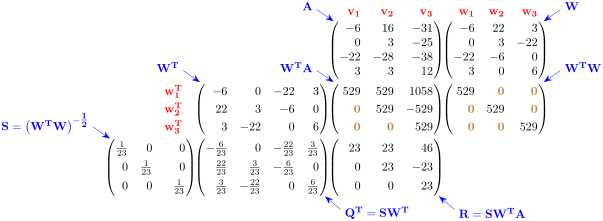

L"$A = Q R = \frac{1}{23} \left(\begin{array}{rrr}
-6 & 22 & 3 \\
0 & 3 & -22 \\
-22 & -6 & 0 \\
3 & 0 & 6 \\
\end{array}\right) \left(\begin{array}{rrr}
23 & 23 & 46 \\
0 & 23 & -23 \\
0 & 0 & 23 \\
\end{array}\right)$"

Q' * Q == I = true
A == Q * R = true


In [26]:
h, qr_spec = qr_bundle(A; fig_scale=1.2)  # renders layout
display(h)

Q = q_factor_from_spec(qr_spec)
R = r_factor_from_spec(qr_spec)
display(l_show( L"A = Q R = ", Q, R))

@show Q'Q ==  I
@show A == Q*R;

#### **Floating Point Representation**

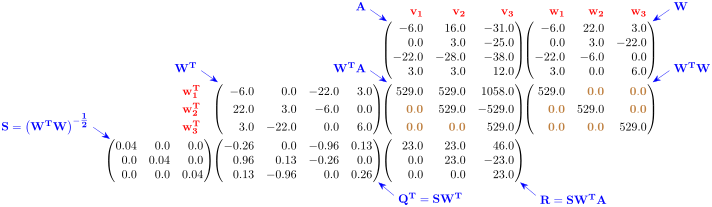

In [27]:
h, _ = qr_figure(1.0*A[:,1:3], formatter=x->string(round(x,digits=2)), fig_scale=1.2)
h

# 3. Eigenproblems

## 3.1 General Case

#### **Real Eigenvalues**

In [28]:
S,Λ,Sinv,A = gen_eigenproblem([-2,-2,0])
d,intA     = factor_out_denominator(A)

l_show( L"A = ", A, L"\qquad p(\lambda) = %$(charpoly(A))" )

L"$A = \left(\begin{array}{rrr}
-14 & 0 & 6 \\
12 & -2 & -6 \\
-28 & 0 & 12 \\
\end{array}\right) \qquad p(\lambda) = -λ^3 - 4*λ^2 - 4*λ$"

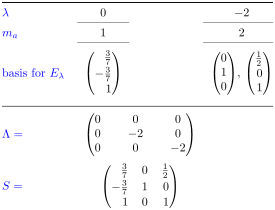

In [29]:
h, eig_spec = eig_bundle(intA, Ascale=d, fig_scale=1.2)
h

#### **Complex Eigenvalues**

In [30]:
S,Λ,Sinv,A = gen_cx_eigenproblem([-2,1+2im])
l_show(L"\qquad A=", A)

L"$\qquad A= \left(\begin{array}{rrr}
-2 & 0 & 0 \\
3 & -1 & -4 \\
-7 & 2 & 3 \\
\end{array}\right)$"

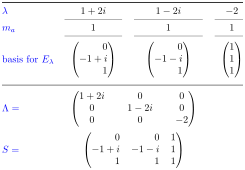

In [31]:
h, _ = eig_bundle(A, fig_scale=1)
h

## 3.2 Failure

In [32]:
A       = gen_non_diagonalizable_eigenproblem(2,0)
#d,intA  = factor_out_denominator(A)

l_show( L"A = ", A, L"\qquad p(\lambda) = %$(charpoly(A))" )

L"$A = \left(\begin{array}{rrr}
-41 & 13 & 4 \\
-89 & 29 & 8 \\
-143 & 43 & 16 \\
\end{array}\right) \qquad p(\lambda) = -λ^3 + 4*λ^2 - 4*λ$"

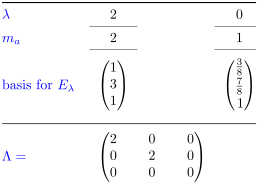

In [33]:
h, eig_spec = eig_bundle(A, fig_scale=1.4)
display(h)

## 3.3 Symmetric Matrix

In [34]:
S,Λ,A   = gen_symmetric_eigenproblem([2,1,0], maxint=2)

l_show( L"A = ", A, L"\qquad p(\lambda) = %$(charpoly(A))" )

L"$A = \frac{1}{49} \left(\begin{array}{rrr}
54 & 6 & 24 \\
6 & 17 & -30 \\
24 & -30 & 76 \\
\end{array}\right) \qquad p(\lambda) = -λ^3 + 3*λ^2 - 2*λ$"

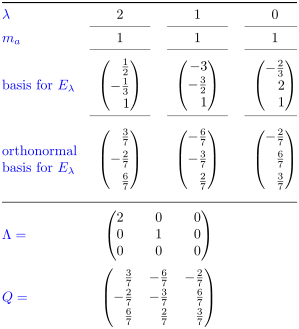

In [35]:
h, eig_spec = eig_bundle(A, normal=true, fig_scale=1.4)
display(h)

## 3.5 SVD

In [36]:
M=3; N=[3,1]; sigmas=[1,-1]   # by splitting N or M into a list of integers
#                             # the matrices become simpler. Here M=3, N=3+1
# ------------------------------------------------------------
U,Σ,Vt,A = gen_svd_problem(3, [3,1],  [1,-1],  maxint=2)

l_show(L"A = ", A, L", \qquad A^{t} A =", A'A )

L"$A = \frac{1}{49} \left(\begin{array}{rrrr}
18 & 9 & -6 & -42 \\
36 & 18 & -12 & 14 \\
-12 & -6 & 4 & -21 \\
\end{array}\right) , \qquad A^{t} A = \frac{1}{49} \left(\begin{array}{rrrr}
36 & 18 & -12 & 0 \\
18 & 9 & -6 & 0 \\
-12 & -6 & 4 & 0 \\
0 & 0 & 0 & 49 \\
\end{array}\right)$"

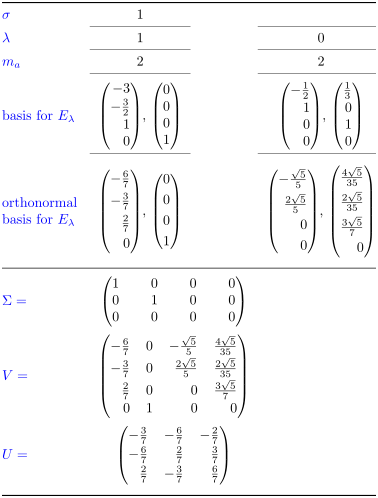

In [37]:
h, svd_spec = svd_bundle(A, fig_scale=1.4)
display(h)

#### PseudoInverse

In [38]:
r    = length(sigmas)
U_r  = U[:,1:r];   dU_r,intU_r = factor_out_denominator(U_r)
V_r  = Matrix(Vt[1:r,:]'); dV_r,intV_r = factor_out_denominator(V_r)
Σ_r  = Σ[1:r,1:r]
dinvΣ_r, invΣ_r = factor_out_denominator(Matrix(Diagonal([1//k for k in diag(Σ_r)])))
pinv_A = V_r * dinvΣ_r * invΣ_r * U_r'

l_show( L"A^\dagger = V_r \Sigma_r^{-1} U_r^t = ",
        V_r, Σ_r, U_r',
        L"= ", pinv_A,
)

L"$A^\dagger = V_r \Sigma_r^{-1} U_r^t = \frac{1}{7} \left(\begin{array}{rr}
0 & 6 \\
0 & 3 \\
0 & -2 \\
-7 & 0 \\
\end{array}\right) \left(\begin{array}{rr}
1 & 0 \\
0 & -1 \\
\end{array}\right) \frac{1}{7} \left(\begin{array}{rrr}
6 & -2 & 3 \\
-3 & -6 & 2 \\
\end{array}\right) = \frac{1}{49} \left(\begin{array}{rrr}
18 & 36 & -12 \\
9 & 18 & -6 \\
-6 & -12 & 4 \\
-42 & 14 & -21 \\
\end{array}\right)$"

In [39]:
@show Float64.(pinv_A) ≈ pinv(A);

Float64.(pinv_A) ≈ pinv(A) = true
